Analizaremos la serie e-commerce orders. Contamos con datos mensuales de ordenes efectuadas a un e-commerce durante un período de 9 años, desde 2016 hasta 2024.
Prof. Victoria Gutiérrez, Guz Vinueza


# 1. Análisis Exploratorio

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Cargar la serie
df = pd.read_csv("ecommerce_orders.csv", parse_dates=[0], index_col=0)

df.head()


,Orders
Month,
2016-01-01,4750
2016-02-01,4625
2016-03-01,4912
2016-04-01,4876
2016-05-01,5154


In [ ]:
df.shape

(108, 1)

Observamos la variable objetivo

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 108 entries, 2016-01-01 to 2024-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Orders  108 non-null    int64
dtypes: int64(1)
memory usage: 1.7 KB


In [ ]:
df.describe()

,Orders
count,108.000000
mean,9230.824074
std,3152.089465
min,4625.000000
25%,6761.500000
50%,8872.500000
75%,11041.250000
max,18596.000000


Observamos la variable tiempo

In [ ]:
print(df.index)
print(type(df.index))

print("\nFrecuencia inferida:", pd.infer_freq(df.index))

print("\nDuplicados en fechas:", df.index.duplicated().sum())

full_range = pd.date_range(df.index.min(), df.index.max(), freq="MS")
missing = full_range.difference(df.index)
print("\nFechas faltantes:", missing)


DatetimeIndex(['2016-01-01', '2016-02-01', '2016-03-01', '2016-04-01',
               '2016-05-01', '2016-06-01', '2016-07-01', '2016-08-01',
               '2016-09-01', '2016-10-01',
               ...
               '2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01',
               '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', name='Month', length=108, freq=None)
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>

Frecuencia inferida: MS

Duplicados en fechas: 0

Fechas faltantes: DatetimeIndex([], dtype='datetime64[ns]', freq='MS')


Graficamos la serie

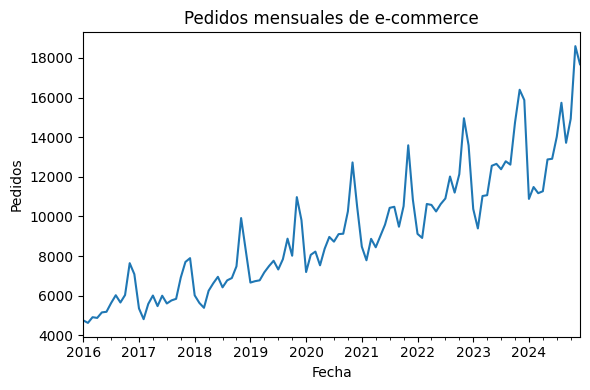

In [ ]:
ts = df["Orders"].asfreq("MS")

# Graficar
plt.figure(figsize=(6,4))
ts.plot(title="Pedidos mensuales de e-commerce", xlabel="Fecha", ylabel="Pedidos")
plt.tight_layout()
plt.show()


Naive forecast for the next period: 17684


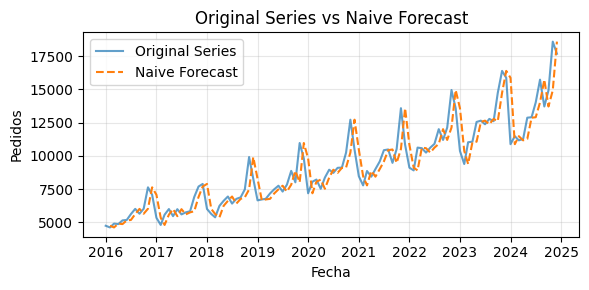

,Orders,Naive_Forecast
Month,,
2016-01-01,4750,NaN
2016-02-01,4625,4750.0
2016-03-01,4912,4625.0
2016-04-01,4876,4912.0
2016-05-01,5154,4876.0


,Orders,Naive_Forecast
Month,,
2024-08-01,15738,14025.0
2024-09-01,13718,15738.0
2024-10-01,14930,13718.0
2024-11-01,18596,14930.0
2024-12-01,17684,18596.0


In [ ]:
# Create a new column for naive predictions
df['Naive_Forecast'] = df['Orders'].shift(1)

# Plot original series and naive forecast
plt.figure(figsize=(6, 3))
plt.plot(df['Orders'], label='Original Series', alpha=0.7)
plt.plot(df['Naive_Forecast'], label='Naive Forecast', linestyle='--')
plt.title('Original Series vs Naive Forecast')
plt.xlabel('Fecha')
plt.ylabel('Pedidos')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(df.head())
display(df.tail())

# 2. Media Móvil

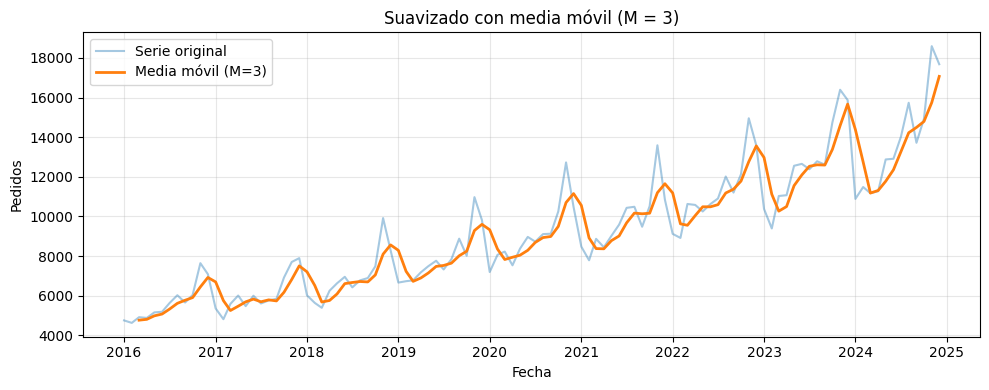

In [ ]:
# Media móvil con M = 3
ma_3 = ts.rolling(3).mean()

plt.figure(figsize=(10,4))
plt.plot(ts, label="Serie original", alpha=0.4)
plt.plot(ma_3, label="Media móvil (M=3)", linewidth=2)
plt.title("Suavizado con media móvil (M = 3)")
plt.xlabel("Fecha")
plt.ylabel("Pedidos")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
comparison_df = pd.DataFrame({'Original Series': ts, 'MA (M=3)': ma_3})
print(comparison_df.head(20))
#print(comparison_df.tail())

            Original Series     MA (M=3)
Month                                   
2016-01-01             4750          NaN
2016-02-01             4625          NaN
2016-03-01             4912  4762.333333
2016-04-01             4876  4804.333333
2016-05-01             5154  4980.666667
2016-06-01             5186  5072.000000
2016-07-01             5629  5323.000000
2016-08-01             6021  5612.000000
2016-09-01             5654  5768.000000
2016-10-01             6031  5902.000000
2016-11-01             7640  6441.666667
2016-12-01             7084  6918.333333
2017-01-01             5354  6692.666667
2017-02-01             4812  5750.000000
2017-03-01             5583  5249.666667
2017-04-01             6006  5467.000000
2017-05-01             5472  5687.000000
2017-06-01             5997  5825.000000
2017-07-01             5605  5691.333333
2017-08-01             5759  5787.000000


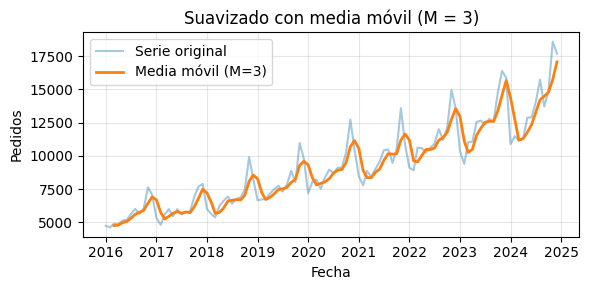

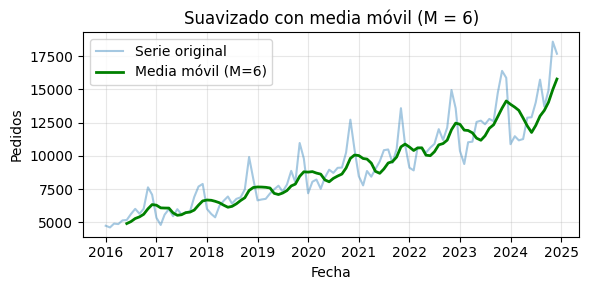

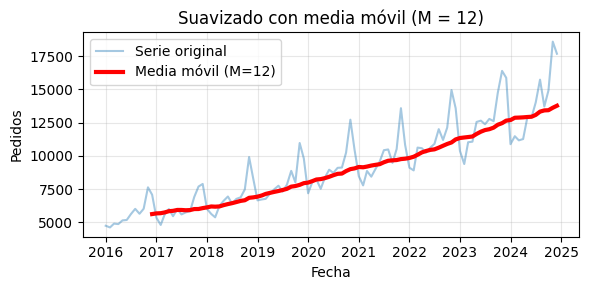

In [ ]:
# Media móvil con M = 3
ma_3 = ts.rolling(3).mean()

plt.figure(figsize=(6,3))
plt.plot(ts, label="Serie original", alpha=0.4)
plt.plot(ma_3, label="Media móvil (M=3)", linewidth=2)
plt.title("Suavizado con media móvil (M = 3)")
plt.xlabel("Fecha")
plt.ylabel("Pedidos")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Media móvil con M = 6
ma_6 = ts.rolling(6).mean()

plt.figure(figsize=(6,3))
plt.plot(ts, label="Serie original", alpha=0.4)
plt.plot(ma_6, label="Media móvil (M=6)", linewidth=2, color="green")
plt.title("Suavizado con media móvil (M = 6)")
plt.xlabel("Fecha")
plt.ylabel("Pedidos")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Media móvil con M = 12
ma_12 = ts.rolling(12).mean()

plt.figure(figsize=(6,3))
plt.plot(ts, label="Serie original", alpha=0.4)
plt.plot(ma_12, label="Media móvil (M=12)", linewidth=3, color="red")
plt.title("Suavizado con media móvil (M = 12)")
plt.xlabel("Fecha")
plt.ylabel("Pedidos")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


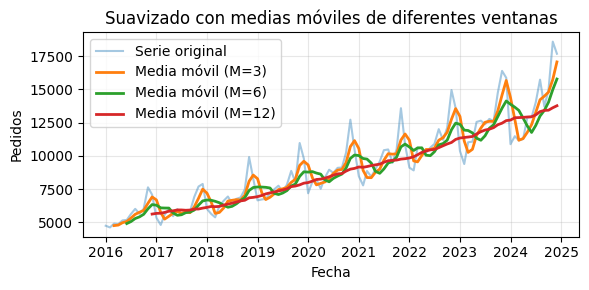

In [ ]:
plt.figure(figsize=(6,3))
plt.plot(ts, label="Serie original", alpha=0.4)
plt.plot(ma_3, label="Media móvil (M=3)", linewidth=2)
plt.plot(ma_6, label="Media móvil (M=6)", linewidth=2)
plt.plot(ma_12, label="Media móvil (M=12)", linewidth=2)
plt.title("Suavizado con medias móviles de diferentes ventanas")
plt.xlabel("Fecha")
plt.ylabel("Pedidos")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

¿Qué componente nos permite captar esta técnica?

¿Qué valor debe tener M para captar esa componente?

Usemos los modelados de media móvil para hacer proyecciones

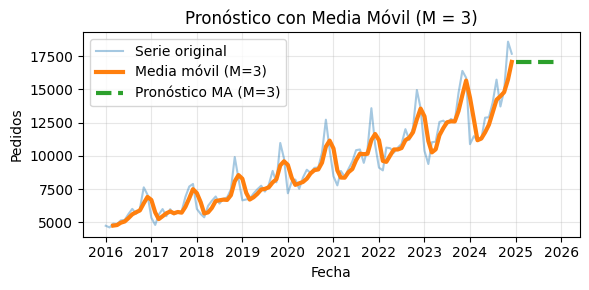

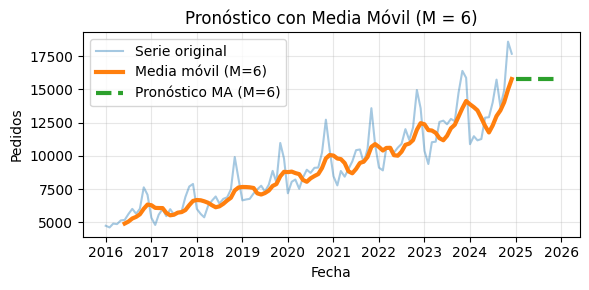

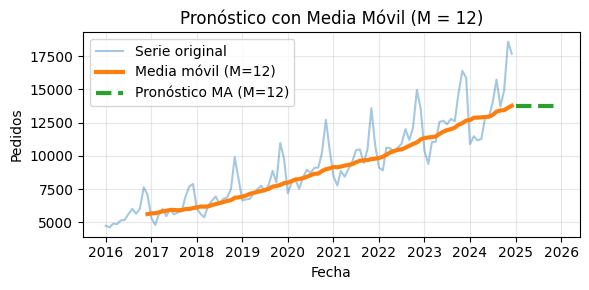

In [ ]:
#Pronósticos
ventanas = [3, 6, 12]
forecast_horizon = 12

for M in ventanas:

    ma = ts.rolling(M).mean()
    last_ma_value = ma.dropna().iloc[-1]
    forecast_index = pd.date_range(start=ts.index[-1] + pd.offsets.MonthBegin(1),
                                   periods=forecast_horizon, freq="MS")

    forecast_ma = pd.Series([last_ma_value] * forecast_horizon, index=forecast_index)

    # Plot
    plt.figure(figsize=(6,3))
    plt.plot(ts, label="Serie original", alpha=0.4)
    plt.plot(ma, label=f"Media móvil (M={M})", linewidth=3)
    plt.plot(forecast_ma, label=f"Pronóstico MA (M={M})", linewidth=3, linestyle="--")
    plt.title(f"Pronóstico con Media Móvil (M = {M})")
    plt.xlabel("Fecha")
    plt.ylabel("Pedidos")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()



# 3. Holt


Ajustamos un modelo a nuestra serie, con tendencia

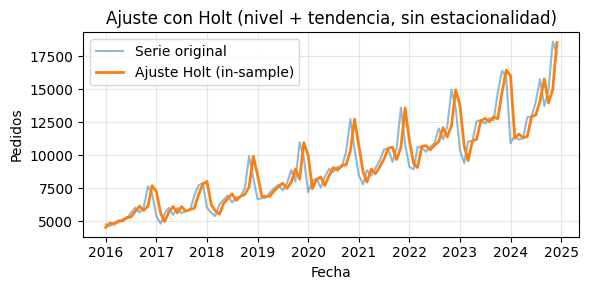

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

holt_model = ExponentialSmoothing(ts, trend="add", seasonal=None, initialization_method="estimated")
holt_fit = holt_model.fit(optimized=True)

plt.figure(figsize=(6,3))
plt.plot(ts, label="Serie original", alpha=0.5)
plt.plot(holt_fit.fittedvalues, label="Ajuste Holt (in-sample)", linewidth=2)
plt.title("Ajuste con Holt (nivel + tendencia, sin estacionalidad)")
plt.xlabel("Fecha")
plt.ylabel("Pedidos")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Usamos el modelo para hacer .  Aquí claramente se ve la tendencia.

Pronóstico 1 período adelante:
2025-01-01    17851.608992
Freq: MS, dtype: float64


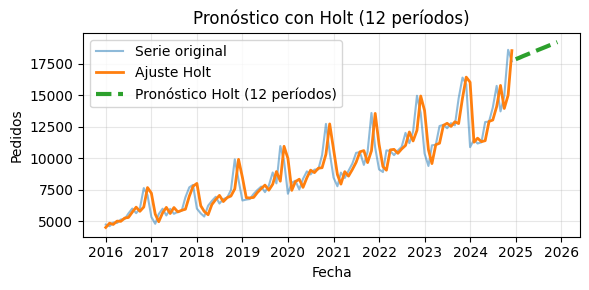

In [ ]:
holt_forecast_1 = holt_fit.forecast(1)
print("Pronóstico 1 período adelante:")
print(holt_forecast_1)

h = 12
holt_forecast_12 = holt_fit.forecast(h)

plt.figure(figsize=(6,3))
plt.plot(ts, label="Serie original", alpha=0.5)
plt.plot(holt_fit.fittedvalues, label="Ajuste Holt", linewidth=2)
plt.plot(holt_forecast_12, label=f"Pronóstico Holt ({h} períodos)", linewidth=3, linestyle="--")
plt.title(f"Pronóstico con Holt ({h} períodos)")
plt.xlabel("Fecha")
plt.ylabel("Pedidos")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


¿Qué componente capta este modelo?

Si aplico este modelo para predecir ordenes de e-commerce, que comportamiento no estoy teniendo en cuenta?

# 4. Winters

Ajustamos un modelo de winters a nuestros datos

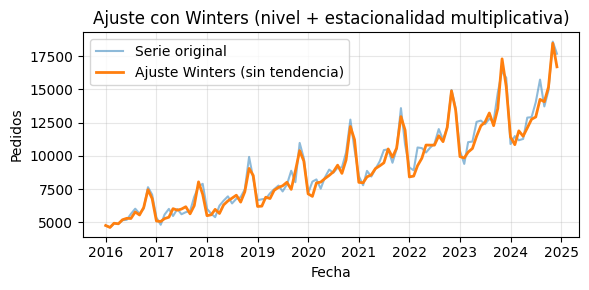

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

winters = ExponentialSmoothing(
    ts,
    trend=None,
    seasonal="mul",
    seasonal_periods=12,
    initialization_method="estimated"
).fit(optimized=True)

plt.figure(figsize=(6,3))
plt.plot(ts, label="Serie original", alpha=0.5)
plt.plot(winters.fittedvalues, label="Ajuste Winters (sin tendencia)", linewidth=2)
plt.title("Ajuste con Winters (nivel + estacionalidad multiplicativa)")
plt.xlabel("Fecha"); plt.ylabel("Pedidos")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()






Hacemos predicciones para los próximos 12 meses

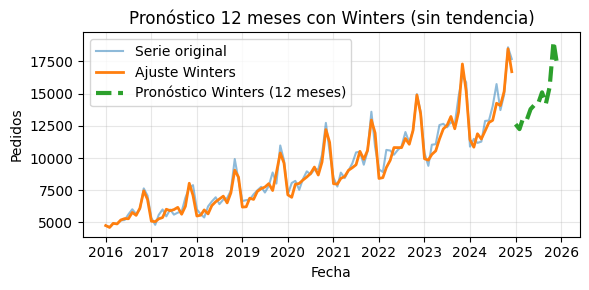

In [ ]:
h = 12
forecast = winters.forecast(h)

plt.figure(figsize=(6,3))
plt.plot(ts, label="Serie original", alpha=0.5)
plt.plot(winters.fittedvalues, label="Ajuste Winters", linewidth=2)
plt.plot(forecast, label=f"Pronóstico Winters ({h} meses)", linewidth=3, linestyle="--")
plt.title(f"Pronóstico 12 meses con Winters (sin tendencia)")
plt.xlabel("Fecha"); plt.ylabel("Pedidos")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

# 5. Holt-Winters

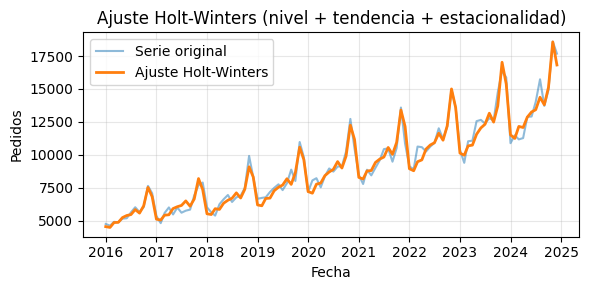

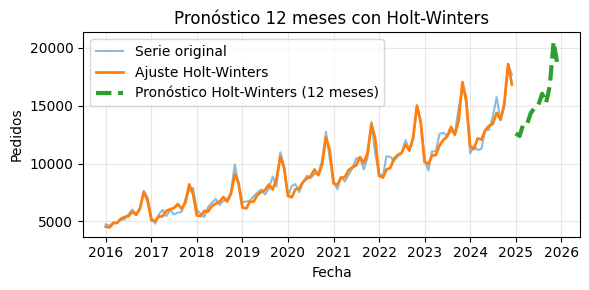

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1) Cargar la serie
df = pd.read_csv("ecommerce_orders.csv", parse_dates=[0], index_col=0)
ts = df["Orders"].asfreq("MS")   # mensual (Month Start)

# 2) Ajustar Holt-Winters (tendencia + estacionalidad)
hw_fit = ExponentialSmoothing(
    ts,
    trend="add",          # tendencia aditiva
    seasonal="mul",       # estacionalidad multiplicativa (cambia con el nivel)
    seasonal_periods=12,  # ciclo anual
    initialization_method="estimated"
).fit(optimized=True)

# 3) Gráfico: ajuste in-sample
plt.figure(figsize=(6,3))
plt.plot(ts, label="Serie original", alpha=0.5)
plt.plot(hw_fit.fittedvalues, label="Ajuste Holt-Winters", linewidth=2)
plt.title("Ajuste Holt-Winters (nivel + tendencia + estacionalidad)")
plt.xlabel("Fecha"); plt.ylabel("Pedidos")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

# 4) Pronóstico a 12 meses
h = 12
hw_forecast = hw_fit.forecast(h)

# 5) Gráfico: pronóstico
plt.figure(figsize=(6, 3))
plt.plot(ts, label="Serie original", alpha=0.5)
plt.plot(hw_fit.fittedvalues, label="Ajuste Holt-Winters", linewidth=2)
plt.plot(hw_forecast, label=f"Pronóstico Holt-Winters ({h} meses)", linewidth=3, linestyle="--")
plt.title(f"Pronóstico 12 meses con Holt-Winters")
plt.xlabel("Fecha"); plt.ylabel("Pedidos")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()



# 6. Analizamos el modelo Holt-Winters

RMSE 2024: 916.63
MAPE 2024: 6.10%

Errores por mes en 2024:
             real  pronostico    error  error_abs  error_%
2024-01-01  10884    11866.30  -982.30     982.30     9.03
2024-02-01  11484    11425.21    58.79      58.79     0.51
2024-03-01  11173    12716.11 -1543.11    1543.11    13.81
2024-04-01  11272    12735.91 -1463.91    1463.91    12.99
2024-05-01  12876    13450.04  -574.04     574.04     4.46
2024-06-01  12911    14007.96 -1096.96    1096.96     8.50
2024-07-01  14025    13982.76    42.24      42.24     0.30
2024-08-01  15738    14683.99  1054.01    1054.01     6.70
2024-09-01  13718    14375.17  -657.17     657.17     4.79
2024-10-01  14930    15803.70  -873.70     873.70     5.85
2024-11-01  18596    19378.54  -782.54     782.54     4.21
2024-12-01  17684    17313.99   370.01     370.01     2.09


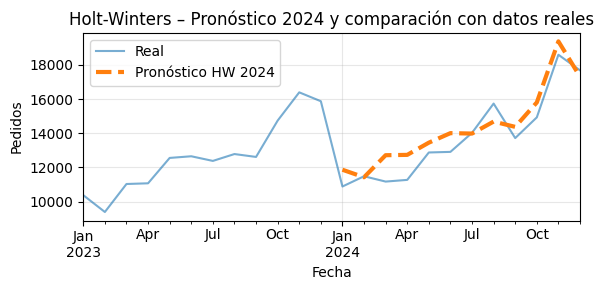

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# -------------------------------
# 1) Cargar serie y separar train/test
# -------------------------------
df = pd.read_csv("ecommerce_orders.csv", parse_dates=[0], index_col=0)
ts = df["Orders"].asfreq("MS")

train = ts[: "2023-12-01"]   # hasta diciembre 2023 inclusive
test  = ts["2024-01-01": "2024-12-01"]  # todo 2024 (12 meses)

# -------------------------------
# 2) Ajustar Holt-Winters en train
#    (tendencia aditiva + estacionalidad multiplicativa)
# -------------------------------
hw = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="mul",
    seasonal_periods=12,
    initialization_method="estimated"
).fit(optimized=True)

# -------------------------------
# 3) Pronosticar 2024
# -------------------------------
h = len(test)  # 12 meses
fcst = hw.forecast(h)
fcst.name = "HW_forecast"

# -------------------------------
# 4) Métricas de error (vs datos reales 2024)
# -------------------------------
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mape(y_true, y_pred, eps=1e-8):
    # eps evita división por cero si hubiera algún 0 (no debería en este dataset)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

rmse_2024 = rmse(test, fcst)
mape_2024 = mape(test, fcst)

print(f"RMSE 2024: {rmse_2024:,.2f}")
print(f"MAPE 2024: {mape_2024:.2f}%")

# (opcional) ver tabla con errores por mes
result = pd.DataFrame({"real": test, "pronostico": fcst})
result["error"] = result["real"] - result["pronostico"]
result["error_abs"] = result["error"].abs()
result["error_%"] = (result["error_abs"] / result["real"]) * 100
print("\nErrores por mes en 2024:")
print(result.round(2))

# -------------------------------
# 5) Gráfico: real (2023-2024) vs pronóstico 2024
# -------------------------------
plt.figure(figsize=(6,3))
ts["2023-01-01":].plot(label="Real", alpha=0.6)     # contexto del último año y pico
fcst.plot(label="Pronóstico HW 2024", linewidth=3, linestyle="--")
plt.title("Holt-Winters – Pronóstico 2024 y comparación con datos reales")
plt.xlabel("Fecha"); plt.ylabel("Pedidos")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()


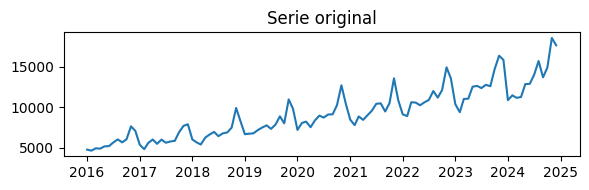

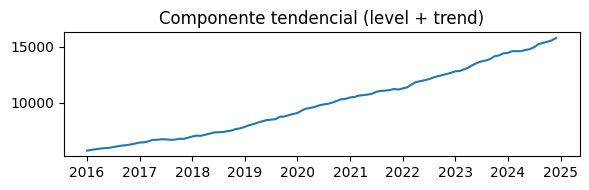

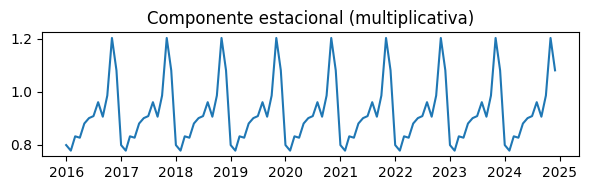

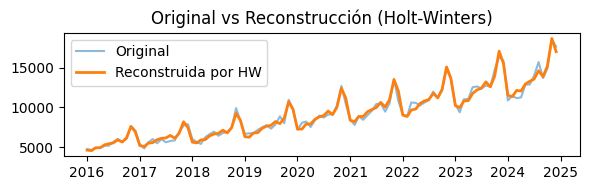

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

#LA TENDENCIA ES ADITIVA Y LA ESTACIONALIDAD MULTIPLICATIVA

# --- elegí el tipo de estacionalidad según tu ajuste ---
SEASONAL_TYPE = "mul"   # "mul" o "add"

# 1) Cargar y ajustar (mismo modelo que venías usando)
df = pd.read_csv("ecommerce_orders.csv", parse_dates=[0], index_col=0)
ts = df["Orders"].asfreq("MS")

hw_fit = ExponentialSmoothing(
    ts,
    trend="add",                 # tendencia aditiva
    seasonal=SEASONAL_TYPE,      # "mul" o "add"
    seasonal_periods=12,
    initialization_method="estimated"
).fit(optimized=True)

# 2) Extraer componentes del resultado
# En statsmodels, los nombres correctos son: level, trend, season
level = pd.Series(getattr(hw_fit, "level"), index=ts.index, name="level")

trend_arr = getattr(hw_fit, "trend", None)  # puede ser None si no hay tendencia
if trend_arr is None:
    trend = pd.Series(0.0, index=ts.index, name="trend")
else:
    trend = pd.Series(trend_arr, index=ts.index, name="trend")

season = pd.Series(getattr(hw_fit, "season"), index=ts.index, name="seasonal")

# 3) Construir "parte tendencial" y la reconstrucción según el tipo
trend_part = (level + trend).rename("trend_part")

if SEASONAL_TYPE == "mul":
    reconstructed = (trend_part * season).rename("reconstructed")
else:  # "add"
    reconstructed = (trend_part + season).rename("reconstructed")

# 4) Graficar “descomposición” del modelo
plt.figure(figsize=(6,2))
plt.plot(ts, label="y")
plt.title("Serie original")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,2))
plt.plot(trend_part, label="level + trend")
plt.title("Componente tendencial (level + trend)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,2))
plt.plot(season, label="season")
plt.title(f"Componente estacional ({'multiplicativa' if SEASONAL_TYPE=='mul' else 'aditiva'})")
plt.tight_layout()
plt.show()

# 5) Verificación: reconstrucción vs original
plt.figure(figsize=(6,2))
plt.plot(ts, label="Original", alpha=0.5)
plt.plot(reconstructed, label="Reconstruida por HW", linewidth=2)
plt.title("Original vs Reconstrucción (Holt-Winters)")
plt.legend()
plt.tight_layout()
plt.show()



RMSE (in-sample): 474.67
MAPE (in-sample): 4.12%
                y    fitted    resid  APE_%
Month                                      
2024-01-01  10884  11514.99  -630.99   5.80
2024-02-01  11484  11244.60   239.40   2.08
2024-03-01  11173  12157.53  -984.53   8.81
2024-04-01  11272  12074.60  -802.60   7.12
2024-05-01  12876  12859.93    16.07   0.12
2024-06-01  12911  13254.87  -343.87   2.66
2024-07-01  14025  13425.33   599.67   4.28
2024-08-01  15738  14371.65  1366.35   8.68
2024-09-01  13718  13800.11   -82.11   0.60
2024-10-01  14930  15122.64  -192.64   1.29
2024-11-01  18596  18574.95    21.05   0.11
2024-12-01  17684  16822.25   861.75   4.87


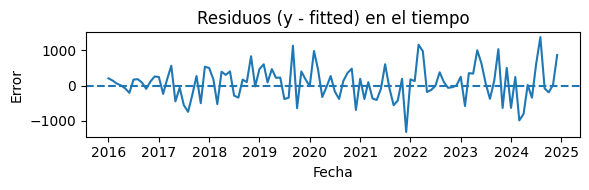

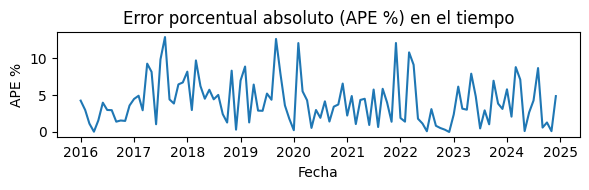

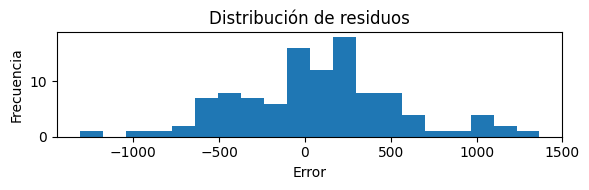

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1) Errores (residuos) y métricas
fitted = hw_fit.fittedvalues
resid = ts - fitted
ape = (resid.abs() / ts) * 100  # Absolute Percentage Error

rmse = np.sqrt(np.mean((resid)**2))
mape = np.mean(ape)

print(f"RMSE (in-sample): {rmse:,.2f}")
print(f"MAPE (in-sample): {mape:.2f}%")

# (opcional) tabla resumida
errors_df = pd.DataFrame({"y": ts, "fitted": fitted, "resid": resid, "APE_%": ape})
print(errors_df.tail(12).round(2))

# 2) Gráfico: Residuos en el tiempo
plt.figure(figsize=(6,2))
plt.plot(resid)
plt.axhline(0, linestyle="--")
plt.title("Residuos (y - fitted) en el tiempo")
plt.xlabel("Fecha"); plt.ylabel("Error")
plt.tight_layout()
plt.show()

# 3) Gráfico: Error porcentual absoluto (APE %)
plt.figure(figsize=(6,2))
plt.plot(ape)
plt.title("Error porcentual absoluto (APE %) en el tiempo")
plt.xlabel("Fecha"); plt.ylabel("APE %")
plt.tight_layout()
plt.show()

# 4) Gráfico: Histograma de residuos
plt.figure(figsize=(6,2))
plt.hist(resid.dropna(), bins=20)
plt.title("Distribución de residuos")
plt.xlabel("Error"); plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()
